In [5]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy
from dask.distributed import Client
from pathlib import Path

In [6]:
base_path = "/gxfs_work/geomar/smomw122/2025_fucus-dispersal/output/Trajectories/"

In [7]:
_ds = []
for experiment_type in ["bottom", "surface", "surface_stokes"]:
    zarr_stores = sorted(Path(base_path).glob(f"{experiment_type}/????/*.zarr"))
    len(zarr_stores)

    zarr_stores = zarr_stores[:5]

    ds = xr.open_mfdataset(zarr_stores, engine="zarr", combine="nested", concat_dim="trajectory")
    ds = ds.assign_coords(trajectory=np.arange(ds.sizes["trajectory"]))
    ds = ds.assign_coords(experiment_type=experiment_type)
    _ds.append(ds)
ds = xr.concat(_ds, dim="experiment_type")
ds

<xarray.Dataset> Size: 331GB
Dimensions:          (experiment_type: 3, trajectory: 436000, obs: 5274)
Coordinates:
  * obs              (obs) int32 21kB 0 1 2 3 4 5 ... 5269 5270 5271 5272 5273
  * trajectory       (trajectory) int64 3MB 0 1 2 3 ... 435997 435998 435999
  * experiment_type  (experiment_type) <U14 168B 'bottom' ... 'surface_stokes'
Data variables:
    age_sec          (experiment_type, trajectory, obs) float32 28GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    cell_ID          (experiment_type, trajectory, obs) float32 28GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    lat              (experiment_type, trajectory, obs) float64 55GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    lon              (experiment_type, trajectory, obs) float64 55GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    max_age_sec      (experiment_type, trajectory, obs) float32 28GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    time             (experiment_type, trajectory, obs) datetime64[ns] 55GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    velocity_factor  (experiment_type, trajectory, obs) float32 28GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
    z                (experiment_type, trajectory, obs) float64 55GB dask.array<chunksize=(1, 10000, 1000), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_BSHmax_age_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

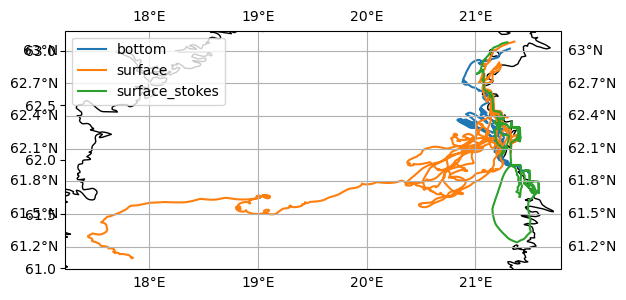

In [17]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": cartopy.crs.PlateCarree()})
for experiment_type in ["bottom", "surface", "surface_stokes"]:
    ax = ds.sel(experiment_type=experiment_type).isel(trajectory=1200, obs=slice(0, -1)).compute().to_dataframe().plot.line(
        x="lon", y="lat", label=experiment_type, ax=ax, transform=cartopy.crs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True)